In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import fg_utils

In [2]:
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['grid.alpha'] = 0.4
matplotlib.rcParams['font.size'] = 12.
matplotlib.rcParams['font.family'] = 'monospace'

In [4]:
lmu_utm  = [262546.0, 8277036.0];
alvo_utm = [263769.0, 8246145.0];

PO1_utm = [262672., 8250238.]
PO4_utm = [266354., 8248861.]

Text(0.5, 1.0, 'sensibilidade : 52.5 metros / grau')

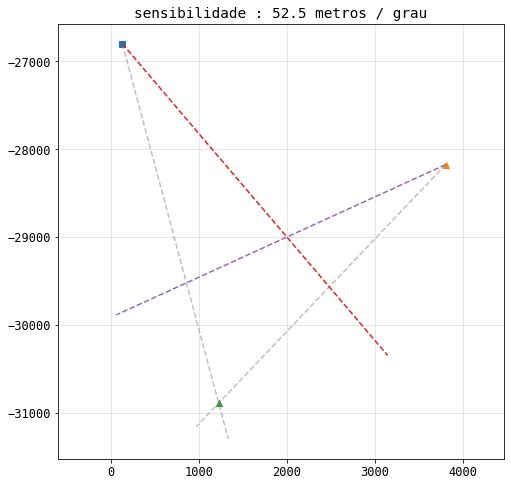

In [12]:
# ajuste posicoes relativas

lmu  = [0., 0.]
alvo = np.subtract(alvo_utm, lmu_utm)
po1  = np.subtract(PO1_utm, lmu_utm)
po2  = np.subtract(PO4_utm, lmu_utm)

def graf(v, marker = 'o', color = None):
    plt.plot(v[0], v[1], marker=marker, color=color)

def calc_ang(ini, ref1, ref2):
    v1 = np.subtract(ref1, ini)
    v2 = np.subtract(ref2, ini)
    
    ang = np.arccos(np.dot(v1,v2)/np.linalg.norm(v1)/np.linalg.norm(v2))*180./np.pi
    
    if (np.cross([*v1, 0.], [*v2, 0.])[2]) > 0.:
        ang = -ang
        
    return ang

def linha(ini=None, ref=None, ang=0., dist=-1, style=None, color=None, alpha=None):
    vec = np.subtract(ref,ini)
    
    if dist < 0.:
        dist = np.linalg.norm(vec)
    
    rad  = ang*np.pi/180.
    
    vec_    = [0., 0.]
    vec_[0] =  vec[0]*np.cos(rad) + vec[1]*np.sin(rad)
    vec_[1] = -vec[0]*np.sin(rad) + vec[1]*np.cos(rad)
    
    vec_ = np.divide(vec_, np.linalg.norm(vec_))*dist
    
    x = [ini[0], ini[0] + vec_[0]]
    y = [ini[1], ini[1] + vec_[1]]
    
    plt.plot(x, y, linestyle=style, color=color, alpha=alpha)

def linha_po1(ang, color=None, alpha=None):
    linha(po1, po2, ang = ang, dist=(dist_po1_alvo*1.1), style='--', color=color, alpha=alpha)

def linha_po2(ang, color=None, alpha=None):
    linha(po2, po1, ang = ang, dist=(dist_po2_alvo*1.1), style='--', color=color, alpha=alpha)

    
graf(po1, marker='s')
graf(po2, marker='^')
graf(alvo, marker='^')

dist_po1_alvo = np.linalg.norm(np.subtract(alvo, po1))
dist_po2_alvo = np.linalg.norm(np.subtract(alvo, po2))

ang01 = calc_ang(po1, po2, alvo)
ang02 = calc_ang(po2, po1, alvo)

linha_po1(ang01, color='gray', alpha=0.5)
linha_po2(ang02, color='gray', alpha=0.5)

plt.grid(1)


plt.axis('equal');

def calc_impacto(ang1, ang2):
    imp = fg_utils.calculo_po([0., ang1, 0., ang2])
    return np.subtract(imp, lmu_utm)
    
def calc_sensibilidade(ponto, res=1.):
    # calculando angulos `ponto`
    ang1 = calc_ang(po1, po2, ponto)
    ang2 = calc_ang(po2, po1, ponto)
    
    # calculando ponto `utm` dos angulos
    i1menos = calc_impacto(ang1 - res, ang2)
    i1mais  = calc_impacto(ang1 + res, ang2)
    
    i2menos = calc_impacto(ang1, ang2 - res)
    i2mais  = calc_impacto(ang1, ang2 + res)
    
    # calculando diferenca em relacao ao `ponto`
    d1menos = np.linalg.norm(np.subtract(i1menos, ponto))
    d1mais  = np.linalg.norm(np.subtract(i1mais, ponto))
    
    d2menos = np.linalg.norm(np.subtract(i2menos, ponto))
    d2mais  = np.linalg.norm(np.subtract(i2mais, ponto))
    
    # calculando media de sensibilidade
    s1 = (d1menos + d1mais)/2.
    s2 = (d2menos + d2mais)/2.
    
    # calculando sensibilidade total
    s  = np.linalg.norm([s1, s2])
    
    # montando saida
    res = {
        'a1': ang1,
        'a2': ang2,
        's1': s1,
        's2': s2,
    }
    
    return res

res = calc_sensibilidade([2000., -29000])

linha_po1(res['a1'])
linha_po2(res['a2'])
plt.title(f'sensibilidade : {res["s1"]:.1f} metros / grau')

In [14]:
N = 30
S1 = np.zeros((N, N))
S2 = np.zeros((N, N))

dif_alvo = 2000.

x0 = alvo[0] - dif_alvo
y0 = alvo[1] - dif_alvo
xf = alvo[0] + dif_alvo
yf = alvo[1] + dif_alvo

# x0 = 0.
# xf = 3500.
# y0 = -28500.
# yf = -32000.

print([x0, xf, y0, yf])

dx = (xf - x0)/N
dy = (yf - y0)/N

for i in range(N):
    for j in range(N):
        x = x0 + dx*i
        y = y0 + dy*j
                
        res = calc_sensibilidade([x,y], res = 1./60.)
        S1[i,j] = res['s1']
        S2[i,j] = res['s2']

[-777.0, 3223.0, -32891.0, -28891.0]


In [15]:
def heat(S, title = None):
    # generate 2 2d grids for the x & y bounds
    x, y = np.meshgrid(np.linspace(x0, xf, N), np.linspace(y0, yf, N))

    #z_min, z_max = -np.abs(z).max(), np.abs(z).max()
    z = S;
    z_min, z_max = np.abs(z).min(), np.abs(z).max()

    fig, ax = plt.subplots()

    c = ax.pcolormesh(x, y, z, cmap='RdBu', vmin=z_min, vmax=z_max, shading='auto')

    # set the limits of the plot to the limits of the data

    ax.axis([x.min(), x.max(), y.min(), y.max()])
    fig.colorbar(c, ax=ax);

    ax.set_title(f'{title} Erro min: {z_min:.2f} m/min; Erro max: {z_max:.2f} m/min');

    graf(po1, marker='s')
    graf(po2, marker='s')
    graf(alvo, marker='^')
    plt.axis('equal');
    plt.grid(1)

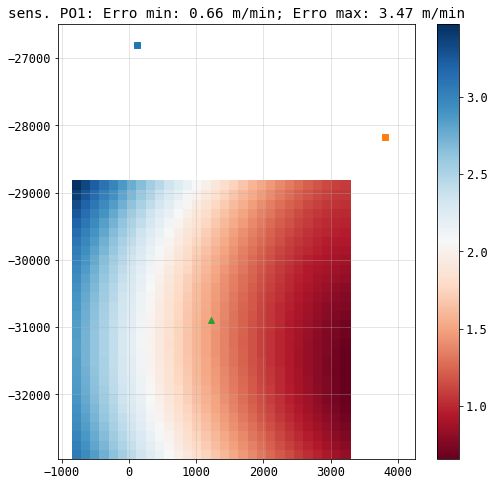

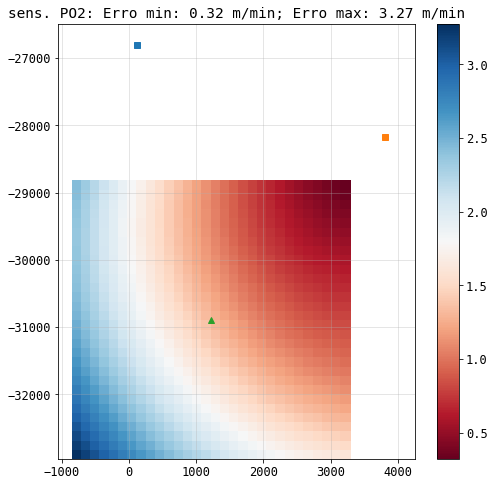

In [27]:
heat(S1, 'sens. PO1:')

heat(S2, 'sens. PO2:')